# Проект. Исследование стартапов

## Введение

### Цели и задачи проекта

**Цель:** исследовать динамику и структуру финансирования стартапов

**Задачи:**
1. Загрузить данные и познакомиться с их содержанием.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
 - Выделить группы компаний по срокам финансирования, сравнить их по количеству и объёму инвестиций;
 - Классифицировать сегменты рынка на массовые, средние и нишевые для дальнейшего анализа;
 - Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования;
 - Сравнить популярность и объёмы разных типов финансирования;
 - Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка;
 - Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
4. Сформулировать выводы по проведенному анализу с рекомендациями. 

### Содержание

1. [Знакомство с данными: загрузка и предобработка](#шаг-1)
- 1.1 [Вывод общей информации](#вывод-общей)
- 1.2 [Предобработка данных](#предобработка-данных)
2. [Инжиниринг признаков](#шаг-2)
- 2.1 [Группы по срокам финансирования](#группы-по)
- 2.2 [Выделение средних и нишевых сегментов рынка](#выделение-средних)
3. [Работа с выбросами и анализ](#шаг-3)
- 3.1 [Анализируем и помечаем выбросы по сегментам](#анализируем-и) 
- 3.2 [Определяем границы периода анализа](#определяем-границы)
- 3.3 [Анализ типов финансирования по объему и популярности](#анализ-типов)
4. [Анализ динамики](#шаг-4)
- 4.1 [Динамика предоставления финансирования по годам](#динамика-предоставления)
- 4.2 [Динамика размера общего финансирования](#динамика-размера)
- 4.3 [Годовая динамика доли возвращенных средств](#годовая-динамика)
5. [Итоговый вывод и рекомендации](#шаг-5)

<a id="шаг-1"></a>
## Шаг 1. Знакомство с данными: загрузка и предобработка

<a id="вывод-общей"></a>
### 1.1. Вывод общей информации

**Начнём с загрузки библиотек и датасетов**. Для исследовательского анализа будем использовать библиотеку `pandas` и библиотеки визуализации данных `matplotlib` и `seaborn`, а также `phik` для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `investments_df` и `returns_df`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
!pip install phik
from phik import phik_matrix

     |████████████████████████████████| 677 kB 2.3 MB/s eta 0:00:01


Загружаем данные из датасетов и сохраняем в переменные: `investments_df` и `returns_df`.

In [2]:
# Выгружаем основной датасет с загрузкой данных из zip-архива
investments_df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

# Выгружаем вспомогательный датасет
returns_df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

Ознакомимся с данными датасета `cb_investments.csv` - выведем общую информацию с помощью метода *info()* и первые строки датасета с помощью метода *head()*

In [3]:
investments_df.info()

count_str_start = investments_df.shape[0]
display(f'Количество строк исходного датафрейма: {count_str_start}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

'Количество строк исходного датафрейма: 54294'

In [4]:
# Выведем все столбцы датасета
pd.set_option('display.max_columns', None)
investments_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Предварительные выводы о датасете `cb_investments.csv`: 

- Датасет `cb_investments.csv` содержит **54294 строки и 40 столбцов**. Данные представлены объемом **16.6 Мб**
- В названиях столбцов `market` и `funding_total_usd` присутствуют лишние пробелы. Названия остальных столбцов приведены к общему стилю snake case 
- Данные хранятся в двух типах: **object** и **float64**. Часть данных требует изменения типа данных на более подходящий, в частности столбцы, хранящие информацию о датах операций
- **Пропуски** содержатся во всех столбцах датасета
- Данные соответствуют описанию

Ознакомимся с данными датасета `cb_returns.csv`:

In [5]:
returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [6]:
returns_df.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [7]:
# Сделаем столбец year индексом датасета returns_df
returns_df = returns_df.set_index('year')

In [8]:
returns_df.head(3)

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0


Предварительные выводы о датасете `cb_returns.csv`: 

- Датасет `cb_returns.csv` содержит **15 строк и 14 столбцов**, размер данных небольшой - **всего 1.8 Кб**
- Названия столбцов приведены к общему стилю
- Большая часть данных, которая содержит информацию о суммах возвратов, хранится в типе данных **object**
- Столбец `year` корректно хранится в типе данных **integer**
- Пропуски в данных отсутствуют. Данные следует проверить на значения-индикаторы, которые укажут на пропущенные значения. 
- Данные соответсвуют описанию

### Промежуточный вывод

Первичное знакомство с данными, показало, что данные представлены в объеме не превышающем 17 Мб. Данные соответствуют описанию и выглядят корректно. В основном датасете содержится большое количество пропусков, требующих обработки. Названия столбцов следует проверить на лишние пробелы и привести к единому стилю. Для части данных требуется изменить тип данных на более подходящий. Для исследовательского анализа, объединять датасеты не потребуется. 

<a id="предобработка-данных"></a>
### 1.2. Предобработка данных

#### Корректировка названий столбцов

В ходе ознакомления с данными, мы выявили, что в названиях столбцов `market` и `funding_total_usd` присутствуют лишние пробелы. Удалим все лишние пробелы в названиях столбцов датасета `investments_df` и приведем все названия к нижнему регистру

In [9]:
# Удаляем лишние пробелы с помощью метода str.strip и приводим к нижнему регистру методом str.lower
investments_df.columns = investments_df.columns.str.strip().str.lower()

In [10]:
# Выведем названия всех столбцов
investments_df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')

#### Оптимизация типов данных

Столбец `funding_total_usd` хранит информацию об объеме инвестиций в долларах США. Денежный формат данных из **object** удобнее привести к числовому типу **float64**. Для приведения к числовому типу данных, дополнительно нужно убрать разделители в виде запятых в значениях столбца.

In [11]:
# Уберем разделители в значениях столбца
investments_df['funding_total_usd'] = investments_df['funding_total_usd'].str.replace(',', '')
# Выведем результат для проверки
investments_df['funding_total_usd'].head(3)

0     90000000 
1      2000000 
2      9000000 
Name: funding_total_usd, dtype: object

Так как во всех столбцах датасета присутствуют пропущенные значения, поменять тип данных на этом этапе не удастся. Мы сделаем это во время обработки пропущенных значений. 

- Столбцы `funding_rounds` и `participants` с типом данных **float64** хранят целочисленные данные, поэтому их удобнее привести к типу **integer**
- Столбцы `founded_at`, `founded_month`,`founded_quarter` и `founded_year` (данные о дате основания компании) не потребуются для анализа, поэтому не будем менять их тип данных
- Столбцы `first_funding_at`, `mid_funding_at`, `last_funding_at` - содержат информацию о датах финансирования, их следует привести к типу данных **datetime64**

#### Обработка пропусков в данных

Выводим информацию о количестве пропусков в столбцах датафрейма `investments_df`

In [12]:
# Расчитаем абсолютное и относительное количество пропусков, сохранипв в переменные:
abs_count = investments_df.isna().sum()
rel_count = investments_df.isna().mean()

# Выведем отдельный датафрейм из пар значений: имя столбца - количество пропусков:
missing_values = pd.DataFrame({'column_name': abs_count.index, 
                               'absolute_count': abs_count.values, 
                               'relative_count': rel_count.values})
# Выводим получившийся датафрейм
display(missing_values)

,column_name,absolute_count,relative_count
0,name,4857,0.089457
1,homepage_url,8305,0.152963
2,category_list,8817,0.162394
3,market,8817,0.162394
4,funding_total_usd,4856,0.089439
5,status,6170,0.113641
6,country_code,10129,0.186558
7,state_code,24133,0.444487
8,region,10129,0.186558
9,city,10972,0.202085


**В данных довольно много пропусков.** Во многих столбцах пропуски в **4856 строках**. Это значение пропусков повторяется во всех столбцах, связанных с **информацией о финансировании**. Данные относятся к типу MCAR. Аналогично, отсутствуют названия компаний в **4857 строках** столбца `name`. Вероятна частичная потеря данных по техническим причинам или отсутствие информации в источниках. Удалим строки с отсутствующей информацией, так как их невозможно восстановить

In [13]:
# Удалим строки с пропусками в столбцах с информацией о компании и инвестициях
investments_df = investments_df.dropna(subset=['first_funding_at', 'name'])
display(investments_df.isna().sum())

# Выведем количество строк датафрейма после удаления данных
count_str_new = investments_df.shape[0]
display(f'Количество строк получившегося датафрейма: {count_str_new}')

name                        0
homepage_url             3449
category_list            3961
market                   3961
funding_total_usd           0
status                   1314
country_code             5272
state_code              19276
region                   5272
city                     6115
funding_rounds              0
participants            18964
founded_at              10884
founded_month           10956
founded_quarter         10956
founded_year            10884
first_funding_at            0
mid_funding_at          19149
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_a                     0
round_b   

'Количество строк получившегося датафрейма: 49437'

Столбец `market` хранит информацию об основной отрасли компании. Для всех пустых значений столбца поставим заглушку в виде индикатора 0, чтобы при анализе выделить эту группу отдельно. Пропуски в данных могут связаны с отсутствием информации на сайте компаний или утерей данных при переносе.

In [14]:
# Заполним пропуски в столбце market индикаторным значением 0
investments_df['market'] = investments_df['market'].fillna(0)
display(investments_df['market'].isna().sum())

0

Пропущенные данные в столбце `mid_funding_at` можно заполнить на основании значений в столбцах `first_funding_at` и `last_funding_at`. Для начала, приведем столбцы к типу данных **datetime64**, затем посчитаем среднее значение интервала

In [15]:
# Приведем столбцы с датами финансирования к типу данных datetime64
# Строки в неверном формате будут преобразованы в NaT (Not a Time)*

for column in ['first_funding_at', 'mid_funding_at', 'last_funding_at']:
    investments_df[column] = pd.to_datetime(investments_df[column], errors='coerce')

**При изменении типа данных, было выявлено, что большая часть данных в каждом из столбцов представлена в формате **'%Y-%m-%d'**, но другая часть - в формате **'%d-%m-%y%'**. Это мешает преобразованию всех данных к одному типу. Такое различие может быть вызвано внесением данных вручную, либо из разных источников

In [16]:
# Проверим, сколько значений перешло в NaT (Not a Time)
display(investments_df[['first_funding_at', 'mid_funding_at', 'last_funding_at']].isna().sum())

first_funding_at       10
mid_funding_at      19149
last_funding_at         6
dtype: int64

In [17]:
# Создаем функцию calculate_mid_funding_at, которая расчитает количество дней между первым и последним финансированием,
# Добавит полученное число дней к дате первого финансирования, получив середину интервала
# И подставит значение в mid_funding_at в случае пропуска. При отсутствии пропуска оставит старое значение

def calculate_mid_funding_at(row):
    if pd.isna(row['mid_funding_at']):
        return row['first_funding_at'] + (row['last_funding_at'] - row['first_funding_at']) / 2
    else:
        return row['mid_funding_at']

investments_df['mid_funding_at'] = investments_df.apply(calculate_mid_funding_at, axis=1)

In [18]:
# Проверим, сколько значений перешло в NaT (Not a Time) теперь
display(investments_df[['first_funding_at', 'mid_funding_at', 'last_funding_at']].isna().sum())

first_funding_at    10
mid_funding_at       8
last_funding_at      6
dtype: int64

Строк, оставшихся в NaT значении не так много, по сравнению с числом строк датафрейма, поэтому удалим их

In [19]:
# Удалим строки с пропусками в самом большом по количеству пропусков стообце first_funding_at
investments_df = investments_df.dropna(subset=['first_funding_at'])

# Проверим, все ли пропуски удалены
display(investments_df[['first_funding_at', 'mid_funding_at', 'last_funding_at']].isna().sum())

# Выведем тип данных обработанных столбцов
display(investments_df[['first_funding_at', 'mid_funding_at', 'last_funding_at']].dtypes)

first_funding_at    0
mid_funding_at      0
last_funding_at     0
dtype: int64

first_funding_at    datetime64[ns]
mid_funding_at      datetime64[ns]
last_funding_at     datetime64[ns]
dtype: object

В описании ничего не говорится о том, за какой **период финансирования** данные. Поэтому выведем минимальное и максимальные значения столбцов первого и последнего финансирования:

In [20]:
# Проверим минимальное и максимальное значения в столбце first_funding_at
min_date = investments_df['first_funding_at'].min()
max_date = investments_df['first_funding_at'].max()

display(f"Период первого финансирования: {min_date} - {max_date}")

'Период первого финансирования: 1921-09-01 00:00:00 - 2014-12-31 00:00:00'

In [21]:
# Проверим минимальное и максимальное значения в столбце last_funding_at
min_date = investments_df['last_funding_at'].min()
max_date = investments_df['last_funding_at'].max()

display(f"Период последнего финансирования: {min_date} - {max_date}")

'Период последнего финансирования: 1921-09-01 00:00:00 - 2015-01-01 00:00:00'

**В датафрейме находятся данные по финансированию от 1921 года до конца 2014 года.**

Столбец `funding_rounds` с типом данных **float64** приведем к типу к типу **integer**, а `participants` - оставим без изменений, так как он не требуется для анализа.

In [22]:
# Преобразуем тип данных столбца funding_rounds в integer
investments_df['funding_rounds'] = investments_df['funding_rounds'].astype('int64')

# Выведем информацию о типе данных столбца funding_rounds
display(investments_df['funding_rounds'].dtype)

dtype('int64')

Пропущенные значения в остальных столбцах можно оставить без изменений, так как они не будут использоваться для анализа

In [23]:
# Выведем количество строк датафрейма после удаления данных
count_str_new = investments_df.shape[0]
display(f'Количество строк получившегося датафрейма: {count_str_new}')

'Количество строк получившегося датафрейма: 49427'

In [24]:
# Посчитаем абсолютное и относительно количество удаленных строк
abs_deleted_str = count_str_start - count_str_new
rel_deleted_str = round((abs_deleted_str/count_str_start)*100, 2)

display(f'В результате обработки пропусков удалено {abs_deleted_str} строк или {rel_deleted_str}%')

'В результате обработки пропусков удалено 4867 строк или 8.96%'

#### Явные и неявные дубликаты в данных

Проверяем данные на наличие явных и неявных дубликатов

In [25]:
# Проверим наличие полных дубликатов в датафрейме investments_df
investments_df.duplicated().sum()

0

In [26]:
# Выведем количество уникальных значений каждого столбца
display(investments_df.nunique())

name                    49340
homepage_url            45839
category_list           16669
market                    939
funding_total_usd       14617
status                      3
country_code              115
state_code                 61
region                   1089
city                     4188
funding_rounds             17
participants               32
founded_at               3369
founded_month             420
founded_quarter           218
founded_year              149
first_funding_at         3904
mid_funding_at           4853
last_funding_at          3651
seed                     3337
venture                  9300
equity_crowdfunding       252
undisclosed               687
convertible_note          299
debt_financing           1872
angel                     999
grant                     532
private_equity            847
post_ipo_equity           239
post_ipo_debt              57
secondary_market           20
product_crowdfunding      176
round_a                  2035
round_b   

In [27]:
# Проверяем уникальные значения в столбцах name, city, funding_total_usd
for column in ['name', 'city', 'funding_total_usd']:
    display(f'Уникальные значения в столбце {column}:')
    display(investments_df[column].sort_values().unique())
    display()

'Уникальные значения в столбце name:'

array(['#waywire', '&TV Communications', "'Rock' Your Paper", ...,
       'zwoor.com', 'µ-GPS Optics', 'ÜberResearch'], dtype=object)

'Уникальные значения в столбце city:'

array(["'s-hertogenbosch", '6 October City', 'A Coruña', ...,
       'Örnsköldsvik', 'Østerby Havn', nan], dtype=object)

'Уникальные значения в столбце funding_total_usd:'

array([' -   ', ' 1 ', ' 100 ', ..., ' 999999 ', ' 9999997 ', ' 9999999 '],
      dtype=object)

In [28]:
# Приведем названия к общему стилю
investments_df['name'] = investments_df['name'].str.strip().str.lower()
investments_df['name'].unique()

array(['harvard university', 'university of new brunswick', 'dupont', ...,
       'digibyte', 'xeltis', 'logovers'], dtype=object)

In [29]:
# Приведем города к общему стилю
investments_df['city'] = investments_df['city'].str.strip().str.lower()
investments_df['city'].unique()

array(['cambridge', nan, 'wilmington', ..., 'north augusta', 'moskva',
       'hermosillo'], dtype=object)

Прочерк в столбце `funding_total_usd` предполагает отсутствие информации о финансировании, поэтому отфильтруем такие значения в данных для дальнейшего анализа

In [30]:
investments_df = investments_df[investments_df['funding_total_usd'] != ' -   ']

Сразу же приведем столбец `funding_total_usd` к типу данных **float64**

In [31]:
investments_df['funding_total_usd'] = investments_df['funding_total_usd'].astype('float64')
investments_df['funding_total_usd'].dtype

dtype('float64')

In [32]:
# Проверяем неявные дубликаты в датафрейме investments_df
investments_df.duplicated(subset=['name', 'city', 'funding_total_usd']).sum()

7

In [33]:
# Выведем строки с неявными дубликаты в датафрейме investments_df
duplicates = investments_df[investments_df.duplicated(subset=['name', 'city', 'funding_total_usd'], keep=False)]
display(duplicates.sort_values(['name','city'], ascending=False))

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
7647,treasure valley urology services,NaN,|Biotechnology|,Biotechnology,332194.0,operating,USA,TX,Austin,austin,4,0.0,2004-01-01,2004-01,2004-Q1,2004.0,2009-09-09,2010-01-14 00:00:00,2014-05-05,45321.0,286873.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8016,treasure valley urology services,NaN,NaN,0,332194.0,operating,USA,TX,Austin,austin,1,0.0,2004-01-01,2004-01,2004-Q1,2004.0,2014-07-18,2010-01-14 00:00:00,2014-07-18,45321.0,286873.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
34082,quest app,http://questapp.co/,|SMS|Android|iPhone|Mobile|,Android,500000.0,operating,USA,CA,SF Bay Area,san francisco,1,NaN,2013-01-01,2013-01,2013-Q1,2013.0,2014-02-10,2014-02-10 00:00:00,2014-02-10,500000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37206,quest app,http://questapp.co,|Curated Web|,Curated Web,500000.0,operating,USA,CA,SF Bay Area,san francisco,1,NaN,2014-01-01,2014-01,2014-Q1,2014.0,2014-01-26,2014-01-26 00:00:00,2014-01-26,500000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
46694,prestigos,http://prestigos.com/,NaN,0,49530.0,operating,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,2013-10-01,2013-10-01 00:00:00,2013-10-01,49530.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
46695,prestigos,http://www.prestigos.info,NaN,0,49530.0,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,2013-10-01,2013-10-01 00:00:00,2013-10-01,49530.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21434,inmarket,http://www.inmarket.com,|Apps|Hardware|Shopping|Retail|Online Reservat...,Mobile,1000000.0,operating,USA,CA,Los Angeles,los angeles,1,2.0,2010-04-01,2010-04,2010-Q2,2010.0,2010-05-01,2010-08-01 00:00:00,2010-05-01,0.0,1000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21444,inmarket,http://www.inmarket.com,|Mobile Shopping|Advertising|Retail|Shopping|M...,Mobile,1000000.0,operating,USA,CA,Los Angeles,los angeles,1,2.0,2010-04-01,2010-04,2010-Q2,2010.0,2010-08-01,2010-08-01 00:00:00,2010-08-01,0.0,1000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44111,gain fitness,http://gainfitness.com,|Fitness|Health and Wellness|,Health and Wellness,2790000.0,operating,USA,CA,SF Bay Area,san francisco,2,5.0,NaN,NaN,NaN,NaN,2011-12-09,2011-12-09 00:00:00,2013-11-06,650000.0,2140000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44112,gain fitness,http://gainfitness.com,|Health and Wellness|,Health and Wellness,2790000.0,operating,USA,CA,SF Bay Area,san francisco,2,5.0,NaN,NaN,NaN,NaN,2011-12-09,2011-12-09 00:00:00,2013-11-06,650000.0,0.0,0.0,0.0,0.0,0.0,2140000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Из 7 строк полностью совпадают только строки о компании `Cue` и `prestigos`. В остальных данных **есть несовпадения в датах финансирования, раундах финансирования или канал привлечения инвестиций.** 

Несовпадение по остальным столбцам может означать, что инвестиции привлекались компанией несколько раз или могут быть следствием ошибок в данных, взятых из разных источников. 

Так как **нет точной информации о характере дублей**, оставим их без изменений. 7 строк из 49427 это 0.015% данных.

Проверим наличие дублей в столбце `market`. Для этого приведем все названия к нижнему регситру и удалим лишнее прибелы

In [34]:
investments_df['market'] = investments_df['market'].str.strip().str.lower()
# выведем уникальные значения
investments_df['market'].nunique()

394

In [35]:
# Выведем количество строк датафрейма после удаления данных по отсутствию информации о финансировании
count_str_end = investments_df.shape[0]
display(f'Количество строк получившегося датафрейма: {count_str_end}')

'Количество строк получившегося датафрейма: 40904'

In [36]:
# Посчитаем абсолютное и относительно количество удаленных строк
abs_deleted_str = count_str_start - count_str_end
rel_deleted_str = round((abs_deleted_str/count_str_start)*100, 2)

display(f'В результате предобработки данных удалено {abs_deleted_str} строк или {rel_deleted_str}%')

'В результате предобработки данных удалено 13390 строк или 24.66%'

In [37]:
# выведем информацию об итоговом датафрейме по завершению обработки
investments_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40904 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40904 non-null  object        
 1   homepage_url          38590 non-null  object        
 2   category_list         38401 non-null  object        
 3   market                38401 non-null  object        
 4   funding_total_usd     40904 non-null  float64       
 5   status                39799 non-null  object        
 6   country_code          37086 non-null  object        
 7   state_code            25618 non-null  object        
 8   region                37086 non-null  object        
 9   city                  36400 non-null  object        
 10  funding_rounds        40904 non-null  int64         
 11  participants          27330 non-null  float64       
 12  founded_at            32198 non-null  object        
 13  founded_month   

### Промежуточный вывод

***В результате предобработки данных:***
1. В **названиях столбцов** `market` и `funding_total_usd` удалены лишние пробелы. Все названия датафрейма `investments_df` приведены к нижнему регистру;
2. В ходе **оптимизации типа данных**:
- Столбец `funding_total_usd` из **object** приведен к числовому типу **float64**так как хранит значения в виде денежных единиц.
- Столбец `funding_rounds`, с типом данных **float64** хранит целочисленные данные, поэтому приведен к типу **integer**
- Столбцы `founded_at`, `founded_month`, `founded_quarter`, `founded_year` (данные о дате основания компании) и `participants` не потребуются для анализа, поэтому их **тип данных не изменен**
- Столбцы `first_funding_at`, `mid_funding_at`, `last_funding_at` - содержат информацию о датах финансирования, поэтому приведены к типу данных **datetime64**
3. В результате обработки **пропусков** удалено **13390 строк или 24.66%**. 
- К удаленным данным относятся все пропуски в столбце `funding_total_usd`, так как эти строки не несут информацию о финансированиях и одна строка без названия компании. 
- Также было удалено **10 строк**, в которых содержалось **некорректное отображение формата дат финансирования**.
- Пропуски в столбце `mid_funding_at` были заполнены на основании значений в столбцах `first_funding_at` и `last_funding_at`
- Пропуски в столбце `market` были заменены на индикатор 0
4. В данных было обраружено **7 строк с неявными дубликатами** по столбцам `name`, `city`, `funding_total_usd`, но за невозможностью определить точныый характер дублей, данные не отбрасывались для дальнейшего анализа. Также в столбце `market` дублирующиеся значения были исключены путем приведения текстовых значений к общему стилю написания;
5. **В датафрейме `investments_df` представлены данные по финансированию от конца 1921 года до конца 2014 года.**
6. **Вспомогательный датафрейм** `returns_df` содержит исходно корректные данные. Изменения не вносились

<a id="шаг-2"></a>
## Шаг 2. Инжиниринг признаков

<a id="группы-по"></a>
### 2.1. Группы по срокам финансирования

**Разделим компании на три группы по количеству и частоте раундов финансирования:**
* Единичное финансирование — был всего один раунд финансирования.
* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.
* Срок финансирования более года.

In [38]:
# Напишем функцию делящую компании на три группы по количеству и частоте раундов финансирования
def stages(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif row['funding_rounds'] > 1 and (row['last_funding_at'] - row['first_funding_at']) < pd.Timedelta(days=365):
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

# Создаем новый столбец с этапами финансирования и применяем функцию к каждой строке нового столбца
investments_df['stages_of_financing'] = investments_df.apply(stages, axis=1)

In [39]:
# Выведем несколько строк с используемыми столбцами для проверки
investments_df[['funding_rounds', 'last_funding_at', 'first_funding_at', 'stages_of_financing']].head(10)

,funding_rounds,last_funding_at,first_funding_at,stages_of_financing
0,1,2014-01-06,2014-01-06,Единичное финансирование
1,1,2014-05-15,2014-05-15,Единичное финансирование
2,1,2009-07-02,2009-07-02,Единичное финансирование
3,3,2014-11-03,2013-11-21,Срок финансирования до года
4,1,2014-01-14,2014-01-14,Единичное финансирование
5,1,2014-10-23,2014-10-23,Единичное финансирование
6,4,2013-12-22,2013-09-05,Срок финансирования до года
7,1,2014-01-12,2014-01-12,Единичное финансирование
8,1,2014-09-30,2014-09-30,Единичное финансирование
9,2,2008-03-01,2007-10-01,Срок финансирования до года


**Вычислим количество и долю компаний в каждой группе финансирования**

In [40]:
display('Распределение компаний по группам финансирования:')

# Посчитаем количество и долю,% компаний в каждой группе
count = investments_df.groupby('stages_of_financing')['name'].count()
shere = round(count/len(investments_df)*100, 2)

# Создаем отдельный датафрейм с количеством и долей
df_finans_group = pd.DataFrame({'count':count,
                                'shere_in_%':shere})
display(df_finans_group)

'Распределение компаний по группам финансирования:'

,count,shere_in_%
stages_of_financing,,
Единичное финансирование,24112,58.95
Срок финансирования более года,12385,30.28
Срок финансирования до года,4407,10.77


**Добавим визуализацию распределения компаний по группам финансирования**

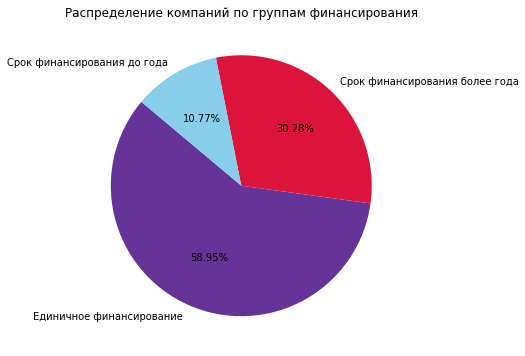

In [41]:
# Посчитаем количество и долю,% компаний в каждой группе
count = investments_df.groupby('stages_of_financing')['name'].count()
shere = count/len(investments_df)*100

# Создаем круговую диаграмму
plt.figure(figsize=(6, 6))
plt.pie(shere, labels=shere.index, autopct='%1.2f%%', startangle=140, colors=['rebeccapurple', 'crimson', 'skyblue'])
plt.title("Распределение компаний по группам финансирования")
plt.show()

Из круговой диаграммы хорошо видно, что большая часть компаний прошла **единичное финансирование (60%)**, в половину меньше группа компаний с несколькими раундами **финансирования до года (30%)** и наименьшая часть - это  компании прошедшие несколько раундов **финансирования сроком более года между первым и последним раундом (11%)**

- **К первой самой большой группе** могут относиться как компании, которые еще только начинают развиваться, и это их первый капитал. Так и те, кто не смогли доказать свою ценность на рынке для продолжения финансирования. Либо стали настолько успешны, что дополнительные вложения извне не потребовались;
- **Вторая группа (до года)** - те, кому очень быстро потребовалось дополнительное вложение, что может быть причиной либо быстрого успешного роста по запросам, либо некорректными затратами в процессе;
- **Третья группа (более года)** - зачастую самая стабильная, где развитие происходит согласно плану

**Определим процентное распределение всего объема инвестиций между группами**

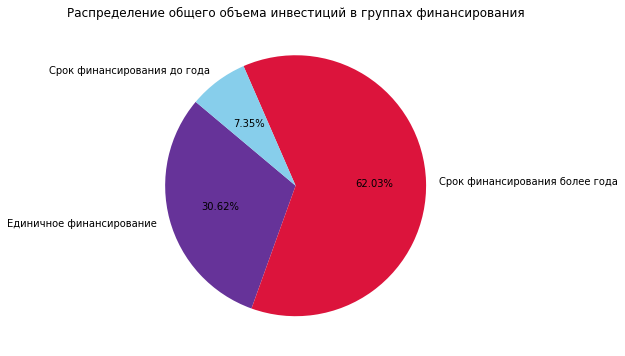

In [42]:
# Сумма всех привлеченных инвестиций в долларах США
total_summa = investments_df['funding_total_usd'].sum()
# Посчитаем сумму инвестиций и долю,% в каждой группе
summa = investments_df.groupby('stages_of_financing')['funding_total_usd'].sum()
shere = summa/total_summa*100

# Создаем круговую диаграмму
plt.figure(figsize=(6, 6))
plt.pie(shere, labels=shere.index, autopct='%1.2f%%', startangle=140, colors=['rebeccapurple', 'crimson', 'skyblue'])
plt.title('Распределение общего объема инвестиций в группах финансирования')
plt.show()

Из диаграммы видно, что хотя группа с единичным финансированием самая многочисленная, объем средств идущих на эту группу (30,6%) в двое меньше, чем поток средств в группу со сроком финансирования более года (62%).

Это может быть связано с тем, что **группа со сроком финансирования более года является наиболее устойчивой и демонстрирует показатели стабильного роста, тем самым вызывая доверие к инвестированию средств в эту группу компаний. Обратный же эффект может наблюдаться в группе с финансированием до года, где объем средств самый небольшой (7,4%)**.

<a id="выделение-средних"></a>
### 2.2 Выделение средних и нишевых сегментов рынка

**Разделим сегменты рынка на три категории по количесву компаний**

- К категории **массовые** будут относиться отрасли рынка с большим количеством компаний (более 120), подлежащих финансированию;
- **Средние** - это отрасли с 35 - 120 компаниями, подлежащих финансированию;
- И **нишевые** - отраслди с наименьшим числом компаний в финансировании (до 35)

In [43]:
# Посчитаем количество компаний в каждом сегменте рынка
count = investments_df.groupby('market')['name'].count()

# Создадим датафрейм с распределением отраслей по категориям
df_groups = pd.DataFrame({'count':count})

# Напишем функцию для выделения категорий сегмента рынка
def market_groups(count):
    if count > 120:
        return 'Массовые'
    elif count > 35 and count < 120:
        return 'Средние'
    elif count > 0 and count < 35:
        return 'Нишевые'
    else:
        return 'Не указан сегмент'

# Создаем новый столбец с категориями отраслей и применяем функцию к каждой строке нового столбца
df_groups['market_group'] = count.apply(market_groups)

In [44]:
# Выведем несколько строк получившегося датафрейма
df_groups.head(7)

,count,market_group
market,,
3d,2,Нишевые
3d printing,3,Нишевые
ad targeting,1,Нишевые
advertising,1107,Массовые
advertising networks,1,Нишевые
advertising platforms,3,Нишевые
aerospace,2,Нишевые


In [45]:
# Посчитаем количество сегментов в каждой категории рынка
count_market = df_groups.groupby('market_group')['count'].count().sort_values(ascending=False)
display(count_market)

market_group
Нишевые     289
Средние      57
Массовые     48
Name: count, dtype: int64

Если в отрасли много компаний, подлежащих финансированию, значит эта область наиболее интересна для финансирования. То есть, наибольший интерес для финансирования представляют **массовые группы**, к которым относится наименьшее число сегментов рынка. 

А большая часть отраслей относятся к **нишевой категории**, где меньше всего компаний подлежащих финансированию. Что закономерно, так как это может быть множество компаний из разных сегментов рынка, получивших разовое финансирование 

Для дальнейшего исследования **перенесем полученные категории в исходный датасет `investments_df`.** 

In [46]:
# Объединяем результаты обратно с исходным датафреймом
investments_df = investments_df.merge(df_groups[['market_group']], left_on='market', right_index=True)

In [47]:
# Выведем несколько столбцов и строк для проверки
investments_df[['name', 'category_list', 'market', 'stages_of_financing', 'market_group']].head()

,name,category_list,market,stages_of_financing,market_group
0,harvard university,|Education|,education,Единичное финансирование,Массовые
3,university of michigan,|Education|,education,Срок финансирования до года,Массовые
4,case western reserve university,|Education|,education,Единичное финансирование,Массовые
6,tulane university,|Education|,education,Срок финансирования до года,Массовые
7,duke university,|Education|,education,Единичное финансирование,Массовые


**Визуализируем распределение компаний по сегментам с разделением на категории**

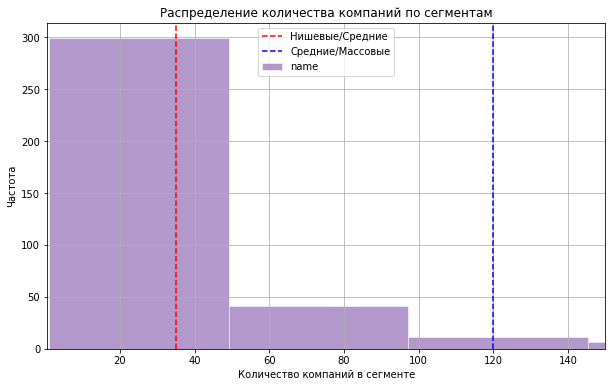

In [48]:
# Задаём размер графика
plt.figure(figsize=(10, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
count.plot(
                kind='hist', 
                bins=100, 
                alpha=0.5,
                color='rebeccapurple',
                edgecolor='white',
                rot=0)

# Добавляем вертикальные линии для разделения сегментов
plt.axvline(x=35, color='red', linestyle='--', label='Нишевые/Средние')
plt.axvline(x=120, color='blue', linestyle='--', label='Средние/Массовые')

# Настраиваем оформление графика
plt.title('Распределение количества компаний по сегментам')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Частота')
plt.legend()
plt.xlim(0.5, 150)

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

На диаграмме мы наблюдаем **правосимметричное распределение** компаний по сегментам рынка. Больная часть значений ниже среднего. Это означает, что большинство компаний уникальны в выбранной нише. Так как речь о финансировании компаний, то условно **"чем больше компаний в категории одного сегмента, тем более интересен этот сегмент для инвестирования"**. Соответственно, те сегменты, где лишь небольшое количество компаний, скорее исключения, более уникальные случаи. 

In [49]:
# Дополнительно выведем список значений с количеством компаний в сегментах рынка
# Так как из-за сильного разброса в частоте не видно хвостовых значений
display(investments_df['market'].value_counts().unique())

array([4812, 3590, 2344, 1866, 1693, 1381, 1185, 1180, 1117, 1107, 1062,
       1003,  873,  844,  828,  667,  596,  567,  484,  424,  349,  336,
        330,  303,  301,  295,  291,  279,  272,  264,  241,  238,  223,
        204,  196,  188,  158,  155,  152,  151,  150,  143,  135,  134,
        132,  111,  109,  106,  101,   98,   94,   93,   87,   85,   81,
         79,   76,   74,   73,   71,   67,   65,   64,   63,   62,   61,
         60,   59,   58,   57,   56,   55,   53,   52,   51,   49,   48,
         47,   46,   45,   43,   39,   25,   22,   15,   14,   12,   11,
         10,    9,    8,    7,    6,    5,    4,    3,    2,    1])

**Рассмотрим на диаграмму размаха распределения компаний по сегментам рынка**

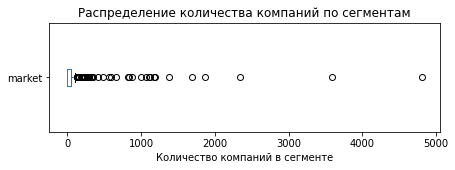

In [50]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

market_count = investments_df['market'].value_counts()
# Строим диаграмму размаха значений в столбце balance
market_count.plot(kind='box', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества компаний по сегментам')
plt.xlabel('Количество компаний в сегменте')

# Выводим график
plt.show()

**Уберем выбросы для детализации основных значений**

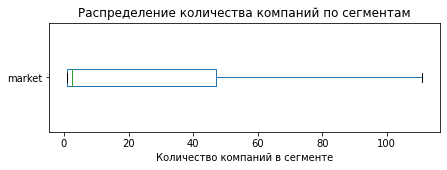

In [51]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

market_count = investments_df['market'].value_counts()
# Строим диаграмму размаха значений в столбце balance
market_count.plot(kind='box', vert=False, showfliers=False) # Исключим выбросы для большей детализации

# Добавляем заголовок и метки оси
plt.title('Распределение количества компаний по сегментам')
plt.xlabel('Количество компаний в сегменте')

# Выводим график
plt.show()

На диаграмме размаха мы видим, что все **значения хранящие более 120 компаний попадают в выбросы**, так как **большая часть компаний распределена между нишевой и средней категориями**. Но нам интересны компании, относящиеся к **массовой категории**, так именно **в этой группе находятся сегменты с самым большим количеством компаний, в которые вкладывались инвестиции**. И следовательно, это самые востребовательные для финансирования отрасли рынка.

Чтобы акцентировать дальнейшее исследование на массовых сегментах рынка, **в столбце `market` оставим значения только для массового сегмента. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.** И будем рассматривать их как два общих сегмента

In [52]:
# Создаем функцию calculate_market, которая построчно проверит столбец market_group
# И подставит нужное значение в market

def calculate_market(row):
    if row['market_group'] == 'Нишевые':
        return 'niche'
    elif row['market_group'] == 'Средние':
        return 'mid'
    else:
        return row['market']

investments_df['market'] = investments_df.apply(calculate_market, axis=1)

In [53]:
# Выведем несколько столбцов и строк для проверки
investments_df[['name', 'category_list', 'market', 'stages_of_financing', 'market_group']].tail()

,name,category_list,market,stages_of_financing,market_group
48719,pacific ethanol,|Business Productivity|Fuels|,niche,Единичное финансирование,Нишевые
48991,golden star resources,|Mining Technologies|Gold|,niche,Единичное финансирование,Нишевые
49434,southgobi resources,|Mining Technologies|,niche,Единичное финансирование,Нишевые
49186,gigbeats,|Musicians|,niche,Единичное финансирование,Нишевые
49260,blackham resources limited,|Gold|,niche,Единичное финансирование,Нишевые


In [54]:
count_str_2 = investments_df.shape[0]
display(f'Количество строк получившегося датафрейма: {count_str_2}')

'Количество строк получившегося датафрейма: 38401'

Основная часть компаний сконцентрирована в одном сегменте - нишевые рынки. Такой разброс указывает на высокую диверсификацию рынка стартапов. Это важно учитывать при оценке инвестиционной привлекательности различных отраслей

<a id="шаг-3"></a>
## Шаг 3. Работа с выбросами и анализ

<a id="анализируем-и"></a>
### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

**Рассмотрим размер общего финансирования в разрезе компаний**

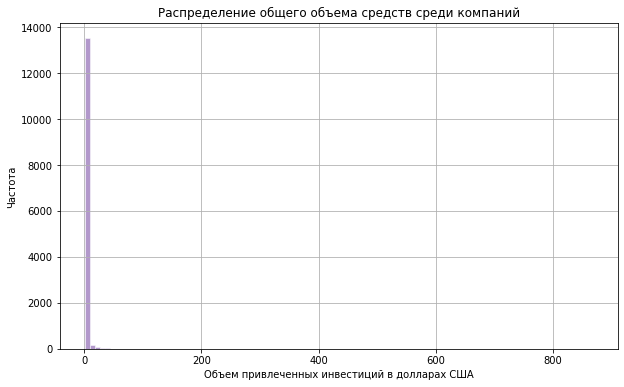

In [55]:
# Задаём размер графика
plt.figure(figsize=(10, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
investments_df['funding_total_usd'].value_counts().plot(
                kind='hist', 
                bins=100, 
                alpha=0.5,
                color='rebeccapurple',
                edgecolor='white',
                rot=0)

# Настраиваем оформление графика
plt.title('Распределение общего объема средств среди компаний')
plt.xlabel('Объем привлеченных инвестиций в долларах США')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

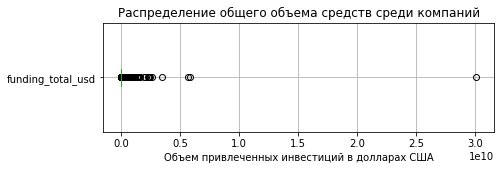

In [56]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
investments_df.boxplot(column='funding_total_usd', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение общего объема средств среди компаний')
plt.xlabel('Объем привлеченных инвестиций в долларах США')

# Выводим график
plt.show()

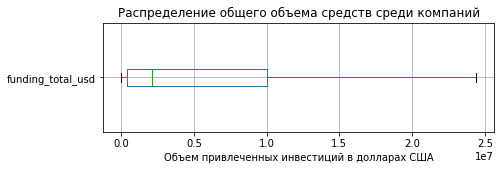

In [57]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
investments_df.boxplot(column='funding_total_usd', vert=False, showfliers=False) # Исключим выбросы для большей детализации

# Добавляем заголовок и метки оси
plt.title('Распределение общего объема средств среди компаний')
plt.xlabel('Объем привлеченных инвестиций в долларах США')

# Выводим график
plt.show()

Из диаграммах мы наблюдаем правосимметричное распределение с большим количеством выбрасов в части данных, лежащих выше среднего значения. Основная часть данных находится в диапозоне **от 500 тыс. до 1 млн долларов США**, но может доходить до 25 млн долларов США.

**С помощью метода IQR определим компании с анамальным объемом общего финансирования по каждому сегменту**

*Для начала получим верхний порог выбросов, затем отберем компании с выбросами выше верхнего порога в рамках сегмента*

In [58]:
# С помощью метода describe получим полную информацию о распределении данных 
# Показатели: count, mean, std, min, квартили: 25%, 50%, 75% и max
total_inf = investments_df.groupby('market')['funding_total_usd'].describe()

# Обратимся к 75% и 25% для вычисления IQR
total_inf['iqr'] = total_inf['75%'] - total_inf['25%']

# Вычислим верхний порог выбросов с коэфф 1.5 (усредненный), так как в нем лежат выбросы на диаграммах
total_inf['high_board'] = total_inf['75%'] + 1.5*total_inf['iqr']

display(total_inf.head())

,count,mean,std,min,25%,50%,75%,max,iqr,high_board
market,,,,,,,,,,
advertising,1107.0,1.306866e+07,4.344897e+07,1000.0,500000.0,2662400.0,11144998.0,1.137000e+09,10644998.0,27112495.00
analytics,667.0,1.400021e+07,6.215029e+07,10000.0,500000.0,2899980.0,11079181.0,1.201000e+09,10579181.0,26947952.50
apps,223.0,2.781719e+06,6.160345e+06,7500.0,100000.0,632000.0,2169575.0,5.000000e+07,2069575.0,5273937.50
automotive,155.0,2.418055e+07,1.338981e+08,500.0,265032.5,2000000.0,10000000.0,1.451000e+09,9734967.5,24602451.25
big data,150.0,1.090578e+07,2.737788e+07,11700.0,300000.0,2000000.0,7000000.0,2.000000e+08,6700000.0,17050000.00


**Найдем интервал типичных значений общего объема средств для компаний**

In [59]:
min_mediana = total_inf['50%'].min()
max_mediana = total_inf['50%'].max()
display(f'Интервал типичных значений общего объема средств для компаний: от {min_mediana} до {max_mediana} долларов США')

'Интервал типичных значений общего объема средств для компаний: от 475000.0 до 12000000.0 долларов США'

Интервал типичных значений общего объема средств для компаний: от 300 тыс. до 11 млн долларов США. Завышенное значение медианы до 11 млн долларов США вероятно связано с долей компаний, получивших аномально высокое финансирование. Так как основное распределение средств лежит в диапозоне от 500 тыс. до 1 млн долларов США

In [60]:
# Объединяем результаты обратно с исходным отфтльтрованным датафреймом
investments_df = investments_df.merge(total_inf[['iqr', 'high_board']], left_on='market', right_index=True)
display(investments_df.head())

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h,stages_of_financing,market_group,iqr,high_board
0,harvard university,http://harvard.edu,|Education|,education,90000000.0,operating,USA,MA,Boston,cambridge,1,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,2014-01-06,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовые,4654415.5,11821079.25
3,university of michigan,http://www.umich.edu/,|Education|,education,7700000.0,operating,USA,MI,Detroit,ann arbor,3,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Срок финансирования до года,Массовые,4654415.5,11821079.25
4,case western reserve university,http://www.case.edu,|Education|,education,540000.0,operating,USA,OH,Cleveland,cleveland,1,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,2014-01-14,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовые,4654415.5,11821079.25
6,tulane university,http://tulane.edu/,|Education|,education,12000000.0,operating,USA,LA,New Orleans,new orleans,4,0.0,1834-01-01,NaN,NaN,1834.0,2013-09-05,2013-09-05,2013-12-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Срок финансирования до года,Массовые,4654415.5,11821079.25
7,duke university,http://www.duke.edu,|Education|,education,8700000.0,operating,USA,NC,Raleigh,durham,1,NaN,1838-01-01,NaN,NaN,1838.0,2014-01-12,2014-01-12,2014-01-12,0.0,8700000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,Массовые,4654415.5,11821079.25


In [61]:
# Приведем данные к числовому типу
investments_df[['iqr', 'high_board']] = investments_df[['iqr', 'high_board']].astype('float64')
display(investments_df[['iqr', 'high_board']].dtypes)

iqr           float64
high_board    float64
dtype: object

**Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.**

In [62]:
# Отфильтруем значения-выбросы (выше верхнего порога)
filt_df = investments_df[investments_df['funding_total_usd'] >= investments_df['high_board']]

# Подсчитываем общее количество компаний
total_companies = filt_df['name'].count()

# Группируем данные по отрасли и подсчитываем количество компаний в каждой группе
grouped_counts = filt_df.groupby('market')['name'].count()

# Вычисляем долю каждой группы относительно общего количества компаний
grouped_shares = grouped_counts / total_companies

display('ТОП-20 сегментов рынка с наибольшей долей компаний, получивших аномальное финансирование:')
# Сортируем доли в порядке убывания и выводим результат
display(grouped_shares.sort_values(ascending=False).head(20))


'ТОП-20 сегментов рынка с наибольшей долей компаний, получивших аномальное финансирование:'

market
software               0.119287
mid                    0.113958
biotechnology          0.078295
mobile                 0.063333
e-commerce             0.055134
curated web            0.041402
clean technology       0.030949
enterprise software    0.030334
advertising            0.027875
social media           0.027875
niche                  0.027055
health care            0.026235
hardware + software    0.025210
games                  0.023980
health and wellness    0.023160
education              0.022956
finance                0.021316
analytics              0.016807
security               0.013527
manufacturing          0.012912
Name: name, dtype: float64

Мы получили ТОП-20 отраслей рынка, получивших аномальное финансирование. Аномалии в финансировании могут быть связаны со множеством факторов. К примеру, инвесторы могут конкурировать за трендовые тенденции рынка: популярное направление исследований с высоким порогом входа или вложения в будущих лидеров рынка. Позиции software (разработка ПО) и biotechnology (биотехнологии) в верхних позициях ТОПа могут демонстрировать трендовые направления исследований

<a id="определяем границы"></a>
### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

**Данные в датасете представлены за большой период с 1921 по 2014 годы**. Обратимся к самым актуальным из них. И проверим полноту данных за 2014 год. Для этого по столбцу last_funding_at проверим первые и последние даты 2014 года

In [63]:
# Провереряем по столбцу last_funding_at так как это крайния дата финансирования
# Выделим год в отдельный столбец
investments_df['last_year'] = investments_df['last_funding_at'].dt.year

# Отберем значения по рассматриваемому году
filtered_df = investments_df[investments_df['last_year'] == 2014]

# Выведем первые и последние 5 значений 2014 года
display(filtered_df[['first_funding_at', 'mid_funding_at', 'last_funding_at']].sort_values(by='last_funding_at').head())
display(filtered_df[['first_funding_at', 'mid_funding_at', 'last_funding_at']].sort_values(by='last_funding_at').tail())

,first_funding_at,mid_funding_at,last_funding_at
36399,2013-09-01,2013-11-01,2014-01-01
47223,2014-01-01,2014-01-01,2014-01-01
12771,2014-01-01,2014-01-01,2014-01-01
24796,2014-01-01,2014-01-01,2014-01-01
12772,2014-01-01,2014-01-01,2014-01-01


,first_funding_at,mid_funding_at,last_funding_at
37512,2014-12-02,2014-12-02,2014-12-02
36837,2014-03-01,2014-07-17,2014-12-02
46073,2013-04-01,2014-01-31,2014-12-02
38413,2014-12-24,2014-12-24,2014-12-24
49437,2014-12-31,2014-12-31,2014-12-31


Первые 5 значений соответствуют первому месяцу 2014 года, а последние 5 - последнему месяцу года. Исходя из этого, можно считать, что в датафрейме полные данные за 2014 год.

**Для дальнейшего исследования отфильтруем данные с аномальными значениями сумм финансирования**

In [64]:
# Исключим значения-выбросы
investments_df = investments_df[investments_df['funding_total_usd'] <= investments_df['high_board']]

In [65]:
count_str_3 = investments_df.shape[0]
display(f'Количество строк получившегося датафрейма: {count_str_3}')

'Количество строк получившегося датафрейма: 33530'

На основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только о тех компаниях, которые должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

То есть, таким образом отберем наиболее успешные и устойчивые на протяжении длительного времени компании

In [66]:
# Выделим год по столбцу mid_funding_at в отдельный столбец
investments_df['mid_year'] = investments_df['mid_funding_at'].dt.year

# Считаем количество раундов за каждый год
rounds_of_year = investments_df.groupby('mid_year')['funding_rounds'].sum()

# Отбираем года, где было 50 или более раундов
year_of_max_rounds = rounds_of_year[rounds_of_year >= 50].index
display(year_of_max_rounds.sort_values(ascending=False))

Int64Index([2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004,
            2003, 2002, 2001, 2000],
           dtype='int64', name='mid_year')

In [67]:
# Отфильтруем исходный датасет, оставив только компании с годами из списка
investments_df = investments_df[investments_df['mid_year'].isin(year_of_max_rounds)]
display(investments_df['mid_year'].unique())

array([2013, 2014, 2010, 2012, 2009, 2011, 2008, 2002, 2006, 2001, 2007,
       2004, 2005, 2003, 2000])

In [68]:
count_str_4 = investments_df.shape[0]
display(f'Количество строк получившегося датафрейма: {count_str_4}')

'Количество строк получившегося датафрейма: 33471'

<a id="анализ-типов"></a>
### 3.3. Анализ типов финансирования по объёму и популярности

**Визуализируем распределение средств в разрезе разных типов финансирования**

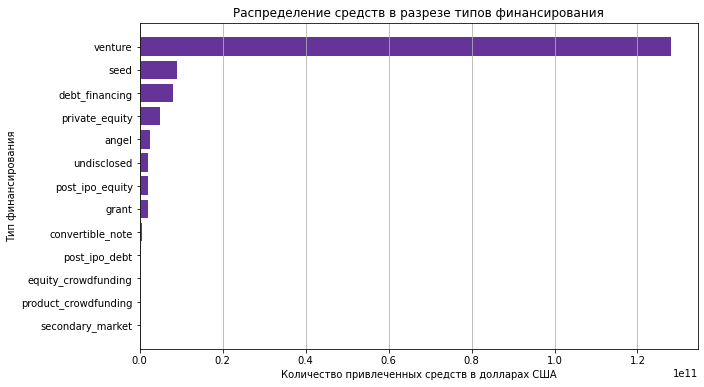

In [69]:
# Считаем количество значений в каждом столбце
column_sum = investments_df[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                             'convertible_note', 'debt_financing', 'angel', 'grant', 
                             'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                             'secondary_market', 'product_crowdfunding']].sum()

# Сортируем значения перед построением графика
column_sum = column_sum.sort_values(ascending=True)

# Создаем график
plt.figure(figsize=(10, 6))
plt.barh(column_sum.index, column_sum.values, color='rebeccapurple')
plt.title('Распределение средств в разрезе типов финансирования')
plt.ylabel('Тип финансирования')
plt.xlabel('Количество привлеченных средств в долларах США')
plt.grid(axis='x')
plt.show()

Из линейчатой диаграммы видно, что **лидирующую позицию по количеству привлеченных средств в размере 120 млрд долларов США представляет сумма венчурных инвестиций**, то есть объем денежных средств, которые инвесторы вкладывают в стартап в обмен на долю в капитале (акции). Остальные типы инвестиций не привышают суммы в 10 млрд долларов США

**Визуализируем популярность типов финансирования среди компаний**

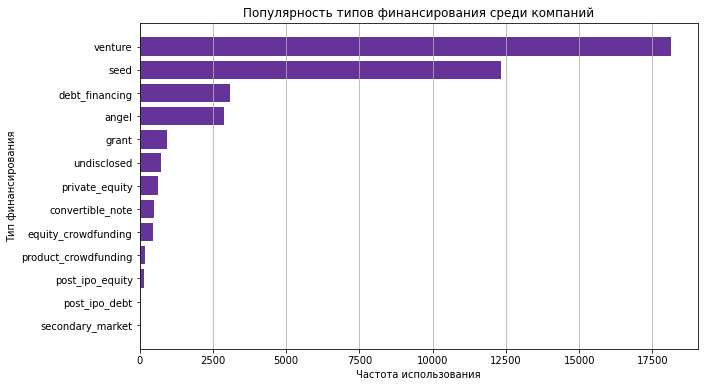

In [70]:
# Считаем количество значений в каждом столбце
column_count = investments_df[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                             'convertible_note', 'debt_financing', 'angel', 'grant', 
                             'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                             'secondary_market', 'product_crowdfunding']].astype('bool').sum()

# Сортируем значения перед построением графика
column_count = column_count.sort_values(ascending=True)

# Создаем график
plt.figure(figsize=(10, 6))
plt.barh(column_count.index, column_count.values, color='rebeccapurple')
plt.title('Популярность типов финансирования среди компаний')
plt.ylabel('Тип финансирования')
plt.xlabel('Частота использования')
plt.grid(axis='x')
plt.show()

Лидирующая позиция по частоте использования типов финансирования снова пренадлежит **венчурным инвестициям (более 17500 компаний)**, однако их догоняют инвестиции на посевной стадии, когда проект уже доказал жизнеспособность (почти 12500 компаний). И, с более 2500 компаниями, с небольшим разрывом идут долговое финансирование (привлечение капитала путем взятия денежных средств в долг с обязательством их возврата с процентами в оговоренный срок) и инвестиции от бизнес-ангелов (вложения частных лиц из их собственных средств).

**Визуализируем объемы возврата средств в разрезе разных типов финансирования по датафрейму `returns_df`**

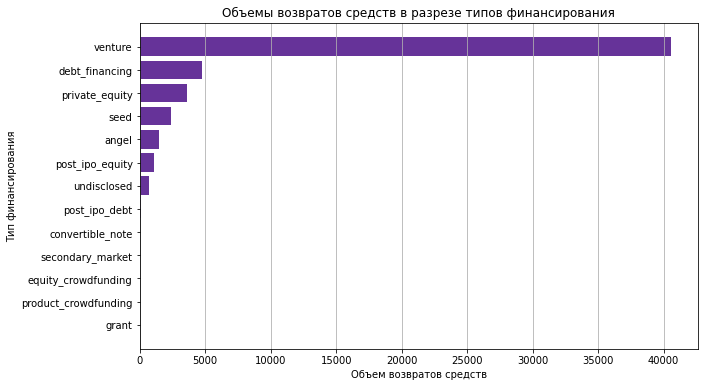

In [71]:
# Считаем количество значений в каждом столбце
columns_sum = returns_df[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                             'convertible_note', 'debt_financing', 'angel', 'grant', 
                             'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                             'secondary_market', 'product_crowdfunding']].sum()

# Сортируем значения перед построением графика
columns_sum = columns_sum.sort_values(ascending=True)

# Создаем график
plt.figure(figsize=(10, 6))
plt.barh(columns_sum.index, columns_sum.values, color='rebeccapurple')
plt.title('Объемы возвратов средств в разрезе типов финансирования')
plt.ylabel('Тип финансирования')
plt.xlabel('Объем возвратов средств')
plt.grid(axis='x')
plt.show()

**Суммы возврата не превышают 40 тыс. долларов США**. Лидируюшая позиция с большим отрывом у венчурных инвестиций. Далее с суммой не превышающей 5 тыс. долларов США идет долговое финансирование.

После того, как мы визуально оценили распределение частоты использования и оборота денежных средств по каждому типу финансирования, посмотрим на **числовые показатели**

In [72]:
# Рассчитаем долю возврата в %
shere = (columns_sum/column_sum)*100

In [73]:
# Выведем отдельно итоговые данные по типам финансирования
df_compare = pd.DataFrame({'Частота_использования':column_count,
                           'Сумма_инвестиции':column_sum,
                           'Сумма_возврата':columns_sum,
                           'Доля_возврата_в_%':shere})
display(df_compare.sort_values(by='Частота_использования', ascending=False))

,Частота_использования,Сумма_инвестиции,Сумма_возврата,Доля_возврата_в_%
venture,18139,1.281119e+11,40578.62,0.000032
seed,12348,9.110730e+09,2382.24,0.000026
debt_financing,3097,8.010603e+09,4734.85,0.000059
angel,2863,2.440582e+09,1509.23,0.000062
grant,918,1.913027e+09,0.00,0.000000
undisclosed,741,2.034127e+09,730.88,0.000036
private_equity,617,4.792806e+09,3587.33,0.000075
convertible_note,501,5.504268e+08,34.79,0.000006
equity_crowdfunding,471,2.265826e+08,3.83,0.000002
product_crowdfunding,195,1.823469e+08,1.86,0.000001


Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

**По всем диаграммам** тип венчурных инвестиций показывает самые высокие показатели по распространенности, сумме вложений и возврата. При этом тип `private_equity`, инвестици в виде прямых (частных) вложений показывает самые хорошие по отдаче результаты. То есть при относительно небольших объемах вложений, получается наибольший процент возврата. Самый частоиспользуемый среди небольших объемов средств тип - `seed`, инвестиции на посевной стадии. А самый большой по объему среди редко используемых - это `post_ipo_equity`, финансирования после IPO (как доп.капитал). И у него тоже высокий процент возврата по сравнению с другими типами финансирования.

<a id="шаг-4"></a>
## Шаг 4. Анализ динамики

**Для каждой компании расчитаем средний объем финансирования за один раунд**

In [74]:
# Выведем новый столбец avg_funding_usd со средним объемом финансирования за 1 раунд
investments_df['avg_funding_usd'] = round(investments_df['funding_total_usd'] / investments_df['funding_rounds'],2)

In [75]:
# выведем несколько столбцов датафрейма
investments_df[['name', 'funding_total_usd', 'funding_rounds', 'avg_funding_usd', 'mid_year']].head()

,name,funding_total_usd,funding_rounds,avg_funding_usd,mid_year
3,university of michigan,7700000.0,3,2566666.67,2013
4,case western reserve university,540000.0,1,540000.00,2014
7,duke university,8700000.0,1,8700000.00,2014
16,michigan state university,3900000.0,1,3900000.00,2014
21,"lsu, baton rouge",2000000.0,1,2000000.00,2013


**Визуализируем динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования**

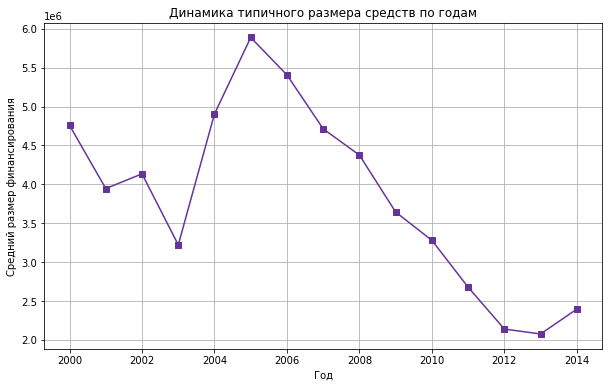

In [76]:
# Группируем данные по году и вычисляем среднее значение финансирования для этого года
avg_fin_per_year = investments_df.groupby('mid_year')['avg_funding_usd'].mean()

# Сортируем значения по годам
avg_fin_per_year = avg_fin_per_year.sort_index()

# Задаем размер графика
plt.figure(figsize=(10, 6))

# Создаем график
plt.plot(avg_fin_per_year.index, avg_fin_per_year.values, marker='s', color='rebeccapurple')
plt.title('Динамика типичного размера средств по годам')
plt.xlabel('Год')
plt.ylabel('Средний размер финансирования')
plt.grid()
plt.show()


Максимальный размер средств, собранных в рамках одного раунда приходится на 2005 год. Его показатель достигает 6 млн долларов США. После 2005 года идет резкий спад размеров финансирования до 2013 года, достигая минимального значения в 2 млн долларов США. И к 2014 году наблюдается небольшой рост до 2,5 млн долларов США.

**Теперь посмотрим на динамику количества раундов за каждый год**

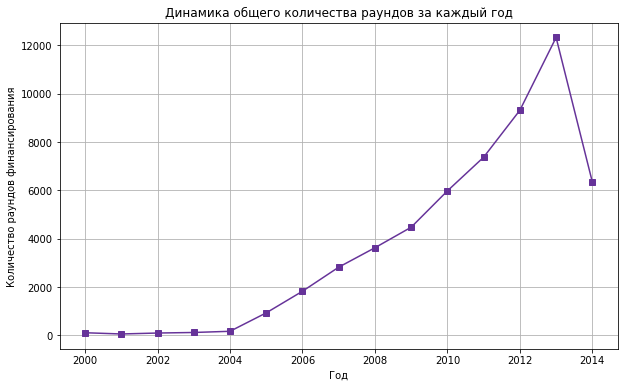

In [77]:
# Группируем данные по году и вычисляем общее число рацндов за год
sum_rounds_per_year = investments_df.groupby('mid_year')['funding_rounds'].sum()

# Сортируем значения по годам
sum_rounds_per_year = sum_rounds_per_year.sort_index()

# Задаем размер графика
plt.figure(figsize=(10, 6))

# Создаем график
plt.plot(sum_rounds_per_year.index, sum_rounds_per_year.values, marker='s', color='rebeccapurple')
plt.title('Динамика общего количества раундов за каждый год')
plt.xlabel('Год')
plt.ylabel('Количество раундов финансирования')
plt.grid()
plt.show()

Так как чем больше раундов, тем выше активность, следовательно можно понять насколько активно происходили инвестиции на рынке. На диаграмме мы наблюдает плато, которое с 2004 года переходит в активный рост до 2013 года. За этот период количество раундов вырастает с покателей близких к 0 до 12 тыс. раундов финансирования за 1 год. И к 2014 году начался спад числа раундов практически вдвое. 

**Промежуточный вывод**: 2013 год характеризуется переломом в структуре сделок: **количество раундов в некоторых сегментах начало снижаться, тогда как общие суммы инвестиций и оценки компаний пошли вверх**. Это может быть связано с тем, что инвесторы стали вкладывать средства в ограниченное число компаний, доказавших свою жизнеспособность и прибыльность. Соответственно к 2014 году такая тенденция сохранилась.

<a id="динамика-размера"></a>
### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

**Понаблюдаем за динамикой размера финансирования в разрезе сегментов рынка**

Выведем суммы финансирования каждого сегмента рынка по годам.

In [78]:
display('Суммарный размер общего финансирования по годам и сегментам рынка:')

# Создаем сводную таблицу
pivot_table = pd.pivot_table(investments_df,
                             index = 'market',
                             columns = 'mid_year',
                             values = 'funding_total_usd',
                             aggfunc = 'sum',
                             fill_value=0) # пропуски заменим на нули

# Отбираем сегменты, где наблюдается рост финансирования в 2014 году по сравнению с 2013
filter_table = pivot_table[pivot_table[2014] > pivot_table[2013]]

# Отображаем отфильтрованную таблицу
display(filter_table)

'Суммарный размер общего финансирования по годам и сегментам рынка:'

mid_year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
apps,0,0,0,0,0,0,1310600,0,4300000,7219000,6123779,18374071,32601125,28868621,66237730
big data,0,0,0,0,0,0,0,7780000,2452515,597375,39233297,60369158,86413341,78698922,79232600
design,0,0,0,0,0,9300000,707000,10800000,5944302,2150144,17239975,8899967,39630692,60958835,68988516
internet,10000000,0,1100000,0,10500000,1775000,5000,4495379,23412964,38195773,36657500,36859032,28288685,69732096,117830756
manufacturing,56659310,2368582,0,4269608,3000000,61770000,163957751,147726051,173054260,422862531,244329661,561639285,522205168,393936634,416332314
medical,24000000,0,0,0,0,11090000,20250000,2100000,28812744,11566200,25590338,28540962,44039600,64469424,175236064
mid,82440389,9441026,18885799,43238404,54438160,214407455,347522579,503542893,550374758,634065533,897182321,890133430,1378138268,1686905096,1868755421
niche,14600000,24020000,0,0,0,0,11180000,44494637,22279331,20754888,18659455,97552701,51648120,269904287,738172920
real estate,2500000,0,5275000,6292200,0,250000,2080000,33220000,46613100,38840213,37344608,20015128,77320857,92207655,115567364


Оставим только те данные, где содержатся данные по всем сегментам за полный год (с 2008 по 2014 гг.). Помимо этого, отфильтруем сегменты средних и нишевых категорий рынка, оставив только массовые.

In [79]:
# Отбираем сегменты, где содержатся полные данные за весь год, т.е. 2008-2014 гг
filter_plot_table = filter_table.loc[:, (filter_table.columns >= 2008)]

# Отбираем только массовые сегменты, без средних и нишевых
filter_plot_table = filter_plot_table[(filter_plot_table.index != 'mid') & (filter_plot_table.index != 'niche')]

display(filter_plot_table)

mid_year,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,
apps,4300000,7219000,6123779,18374071,32601125,28868621,66237730
big data,2452515,597375,39233297,60369158,86413341,78698922,79232600
design,5944302,2150144,17239975,8899967,39630692,60958835,68988516
internet,23412964,38195773,36657500,36859032,28288685,69732096,117830756
manufacturing,173054260,422862531,244329661,561639285,522205168,393936634,416332314
medical,28812744,11566200,25590338,28540962,44039600,64469424,175236064
real estate,46613100,38840213,37344608,20015128,77320857,92207655,115567364
saas,27226900,13536585,32609390,32223749,49699912,79576613,92807752
startups,5010387,460700,2111966,19654403,12333782,18080552,41501837


**Визуализируем изменение размера финансирования в сегментах рынка по годам**

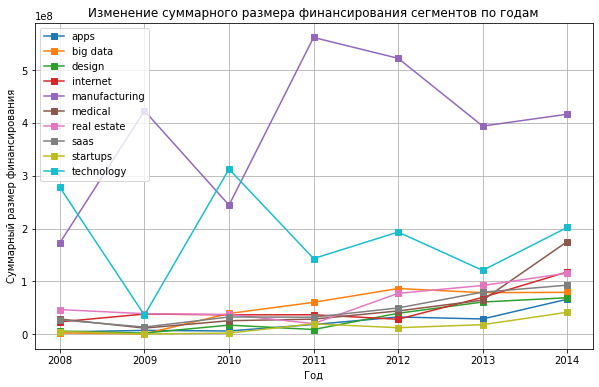

In [80]:
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график из сводной таблицы
# Для оси x - columns, для оси y значения в таблице, соответствубщие market
for market in filter_plot_table.index:
    plt.plot(filter_plot_table.columns, filter_plot_table.loc[market], marker='s', label=market)

plt.title('Изменение суммарного размера финансирования сегментов по годам')
plt.xlabel('Год')
plt.ylabel('Суммарный размер финансирования')
plt.legend(loc='upper left') # расположение легенды
plt.grid()
plt.show()

Из визуализации и данных у `medical` наблюдается самый стабильный рост размеров финансирования. Однако по линейной зависимости, можно сказать, что после 2010 года сильно выросли инвестиции в сегменте `manufacturing`, что может говорить о смещении интереса инвесторов в сторону производства

<a id="годовая-динамика"></a>
### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

**Посчитаем суммы привлеченных финансов и возвратов по каждому типу финансирования за каждый год**

In [81]:
# Считаем суммы привлеченных финансов по годам в каждом виде финансирования
sum_funding_per_year = investments_df.groupby('mid_year')[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                             'convertible_note', 'debt_financing', 'angel', 'grant', 
                             'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                             'secondary_market', 'product_crowdfunding']].sum()

In [82]:
# Считаем суммы возвратов по годам в каждом виде финансирования
sum_returns_per_year = returns_df.groupby('year')[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
                             'convertible_note', 'debt_financing', 'angel', 'grant', 
                             'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
                             'secondary_market', 'product_crowdfunding']].sum()

**Рассчитаем долю возврата средств в каждом типе финансирования по годам**

In [83]:
shere_of_returns_per_year = sum_returns_per_year / (sum_funding_per_year + 1e-60)

display(shere_of_returns_per_year)

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,9.985566e-07,1.698565e-07,0.000000e+00,6.970424e-07,0.000000e+00,6.185714e-07,2.669564e-07,0.0,0.000000e+00,2.710694e-07,0.000000e+00,2.591054e-08,0.000000e+00
2001,1.079592e-06,1.115338e-07,0.000000e+00,5.874833e-07,6.666667e-09,1.740838e-06,1.180000e-06,0.0,0.000000e+00,4.600000e+59,0.000000e+00,4.600000e+59,0.000000e+00
2002,6.297066e-07,6.828204e-07,0.000000e+00,6.088783e-07,2.000000e+58,2.233882e-07,1.136667e-06,0.0,2.013333e-07,1.133333e-06,0.000000e+00,6.000000e+58,0.000000e+00
2003,5.377481e-07,6.337597e-07,0.000000e+00,9.143969e-07,1.000000e+58,1.038095e-06,6.057203e-07,0.0,1.620000e+60,2.110000e+60,0.000000e+00,8.000000e+58,0.000000e+00
2004,5.561552e-07,8.424009e-07,0.000000e+00,5.667187e-07,1.000000e+58,4.702147e-07,8.335043e-07,0.0,2.190000e+60,3.380000e+60,0.000000e+00,5.500000e+59,0.000000e+00
2005,7.775617e-07,5.489273e-07,0.000000e+00,1.529281e-06,2.000000e+58,3.449644e-07,5.098940e-07,0.0,4.800000e-07,7.318565e-07,0.000000e+00,5.000000e+58,0.000000e+00
2006,9.341115e-07,3.450727e-07,1.900000e+59,8.034343e-07,1.663181e-07,8.290833e-07,6.759994e-07,0.0,9.478808e-07,2.058000e+61,0.000000e+00,1.200000e+59,0.000000e+00
2007,3.682021e-07,2.979750e-07,1.000000e+58,5.049708e-07,2.280972e-07,6.024881e-07,8.258433e-07,0.0,5.901127e-07,2.030000e-06,0.000000e+00,5.700000e+59,0.000000e+00
2008,3.015869e-07,1.913012e-07,3.000000e+58,3.488738e-07,6.984493e-08,9.306756e-07,4.141556e-07,0.0,6.799254e-07,2.341111e-06,0.000000e+00,4.700000e+59,0.000000e+00


В данных наблюдаются аномально большие значения. Выведем максимальные значения по всем отрослям

In [84]:
display(shere_of_returns_per_year.max())

seed                    1.079592e-06
venture                 8.424009e-07
equity_crowdfunding     1.900000e+59
undisclosed             1.529281e-06
convertible_note        2.000000e+58
debt_financing          1.740838e-06
angel                   1.204979e-06
grant                   0.000000e+00
private_equity          2.190000e+60
post_ipo_equity         2.058000e+61
post_ipo_debt           9.806452e-07
secondary_market        8.100000e+59
product_crowdfunding    6.857143e-08
dtype: float64

Так как речь о доли, то отфильтруем все значения, которые больше 1, заменив на пропуски

In [85]:
for column in shere_of_returns_per_year.columns:
    for index, value in shere_of_returns_per_year[column].items():
        if value > 1:
            shere_of_returns_per_year.at[index, column] = float('nan')
            
display(shere_of_returns_per_year.head())

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,9.985566e-07,1.698565e-07,0.0,6.970424e-07,0.000000e+00,6.185714e-07,2.669564e-07,0.0,0.000000e+00,2.710694e-07,0.0,2.591054e-08,0.0
2001,1.079592e-06,1.115338e-07,0.0,5.874833e-07,6.666667e-09,1.740838e-06,1.180000e-06,0.0,0.000000e+00,NaN,0.0,NaN,0.0
2002,6.297066e-07,6.828204e-07,0.0,6.088783e-07,NaN,2.233882e-07,1.136667e-06,0.0,2.013333e-07,1.133333e-06,0.0,NaN,0.0
2003,5.377481e-07,6.337597e-07,0.0,9.143969e-07,NaN,1.038095e-06,6.057203e-07,0.0,NaN,NaN,0.0,NaN,0.0
2004,5.561552e-07,8.424009e-07,0.0,5.667187e-07,NaN,4.702147e-07,8.335043e-07,0.0,NaN,NaN,0.0,NaN,0.0


Для проверки повторно выведем максимальные значения. Убедимся, что высоких нет.

In [86]:
display(shere_of_returns_per_year.max())

seed                    1.079592e-06
venture                 8.424009e-07
equity_crowdfunding     1.180413e-07
undisclosed             1.529281e-06
convertible_note        2.280972e-07
debt_financing          1.740838e-06
angel                   1.204979e-06
grant                   0.000000e+00
private_equity          1.136350e-06
post_ipo_equity         2.341111e-06
post_ipo_debt           9.806452e-07
secondary_market        8.571429e-07
product_crowdfunding    6.857143e-08
dtype: float64

Отфильтруем данные по интересующим нас отрослям рынка, которые продемонстрировали интересные показатели в предыдущем разделе. Среди них: `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

In [87]:
shere_of_returns_per_year = shere_of_returns_per_year[['venture', 'debt_financing', 'private_equity', 'seed', 'angel']]

display(shere_of_returns_per_year.head())

,venture,debt_financing,private_equity,seed,angel
year,,,,,
2000,1.698565e-07,6.185714e-07,0.000000e+00,9.985566e-07,2.669564e-07
2001,1.115338e-07,1.740838e-06,0.000000e+00,1.079592e-06,1.180000e-06
2002,6.828204e-07,2.233882e-07,2.013333e-07,6.297066e-07,1.136667e-06
2003,6.337597e-07,1.038095e-06,NaN,5.377481e-07,6.057203e-07
2004,8.424009e-07,4.702147e-07,NaN,5.561552e-07,8.335043e-07


**Построим график, который покажет тенденцию изменения доли возврата средств по годам для каждой выбранной отрасли**

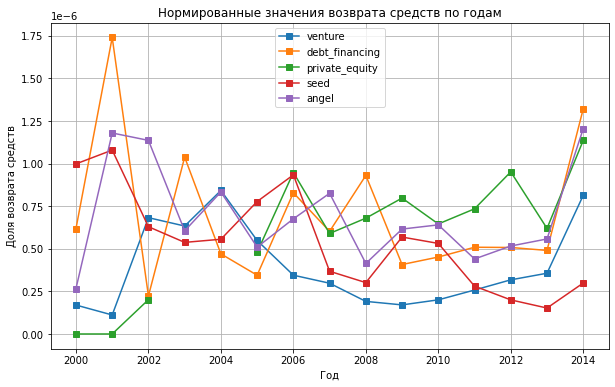

In [88]:
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим график
for column in shere_of_returns_per_year.columns:
    plt.plot(shere_of_returns_per_year.index, shere_of_returns_per_year[column], marker='s', label=column)

plt.title('Нормированные значения возврата средств по годам')
plt.xlabel('Год')
plt.ylabel('Доля возврата средств')
plt.legend(loc='upper center')  # расположение легенды
plt.grid()
plt.show()

Из визуализации прослеживается резкий скачкообразный рост долгового финансирования `debt_financing`. Наиболее устойчивым и предсказуемым являются инвестиции на посевной стадии `seed` без экстремальных скачков вверх-вниз.

### Промежуточный вывод

1. **Исследование компаний**: 

Мы разделили компании на три группы по количеству и срокам прошедших рангов финансирования:

 - К первой самой большой группе (**единичное финансирование - 60%**) могут относиться как компании, которые еще только начинают развиваться, и это их первый капитал. Так и те, кто не смогли доказать свою ценность на рынке для продолжения финансирования. Либо стали настолько успешны, что дополнительные вложения извне не потребовались;
 - Вторая группа (**раунд до года - 30%**) - те, кому очень быстро потребовалось дополнительное вложение, что может быть причиной либо быстрого успешного роста по запросам, либо некорректными затратами в процессе;
 - Третья группа (**раунд более года 11%**) - зачастую самая стабильная, где развитие происходит согласно плану

Чем больше компаний в категории одного сегмента, тем более интересен этот сегмент для инвестирования. То есть, **наибольший интерес для финансирования представляют массовые группы**, к которым относится наименьшее число сегментов рынка.

**Группа со сроком финансирования более года является наиболее устойчивой и демонстрирует показатели стабильного роста**, тем самым вызывая доверие к инвестированию средств (62%) в эту группу компаний. Обратный же эффект может наблюдаться в группе с финансированием до года, где объем средств самый небольшой (7,4%).

Основная часть данных в **распределении сумм финансирования среди компаний** находится в диапозоне от 500 тыс. до 1 млн долларов США, но может доходить до 25 млн долларов США.

2. **Анализ сегментов рынка и типов финансирования**:

Мы получили ТОП-20 отраслей рынка, получивших аномальное финансирование. **Аномалии в финансировании** могут быть связаны со множеством факторов. К примеру, инвесторы могут конкурировать за **трендовые тенденции рынка**: популярное направление исследований с высоким порогом входа или вложения в будущих лидеров рынка. Позиции software (разработка ПО) и biotechnology (биотехнологии) в верхних позициях ТОПа могут демонстрировать трендовые направления исследований

**Лидирующую позицию по количеству привлеченных средств в размере 120 млрд долларов США представляет сумма венчурных инвестиций**. Остальные типы инвестиций не привышают суммы в 10 млрд долларов США

Тип венчурных инвестиций показывает самые высокие показатели по распространенности, сумме вложений и возврата. При этом тип `private_equity`, инвестици в виде прямых (частных) вложений показывает **самые хорошие по отдаче результаты**. То есть при относительно небольших объемах вложений, получается наибольший процент возврата. Самый частоиспользуемый среди небольших объемов средств тип - `seed`, инвестиции на посевной стадии. А самый большой по объему среди редко используемых - это `post_ipo_equity`, финансирования после IPO (как доп.капитал). И у него тоже высокий процент возврата по сравнению с другими типами финансирования.

**Суммы возврата** не превышают 40 тыс. долларов США.

3. Динамические показатели:

**Максимальный размер средств, собранных в рамках одного раунда приходится на 2005 год**. Его показатель достигает 6 млн долларов США. После 2005 года идет резкий спад размеров финансирования до 2013 года, достигая минимального значения в 2 млн долларов США. И к 2014 году наблюдается небольшой рост до 2,5 млн долларов США.

**2013 год характеризуется переломом в структуре сделок**: **количество раундов в некоторых сегментах начало снижаться, тогда как общие суммы инвестиций и оценки компаний пошли вверх**. Это может быть связано с тем, что инвесторы стали вкладывать средства в ограниченное число компаний, доказавших свою жизнеспособность и прибыльность. **Соответственно к 2014 году такая тенденция сохранилась**.

**У `medical` наблюдается самый стабильный рост размеров финансирования**.

**Наиболее устойчивым и предсказуемым являются инвестиции на посевной стадии `seed`** без экстремальных скачков вверх-вниз.

<a id="шаг-5"></a>
## Шаг 5. Итоговый вывод и рекомендации

В ходе исследования проанализированы данные **54294 компаний, привлекших внешнее финансирование за период с начала 1921 по 2014 годы**. Данные включали информацию **информацию о компаниях и ее основной деятельности**, такую как название компании, основная отрасль, город расположения, даты основания, статус и прочие. Также в данных содержалась **информация о состоявшихся финансированиях компаний**, к примеру, общий объем привлеченных средств, число раундов финансирования и типы финансирования. Помимо основного датафрейма, был **дополнительный датафрейм, содержащий информацию об объёмах возвратов** по годам и типам финансирования в миллионах долларов. **Акцент исследования** был направлен на понимание в какую отрасль стоит вкладывать финансы и финансирование какого типа это может быть.

#### Основные выводы

1. Наибольший интерес для финансирования представляют массовые группы, к которым относится наименьшее число сегментов рынка. **Группа со сроком финансирования более года является наиболее устойчивой и демонстрирует показатели стабильного роста**. Обратный же эффект может наблюдаться в группе с финансированием до года, где объем средств самый небольшой. **Основная часть данных в распределении сумм финансирования среди компаний находится в диапозоне от 500 тыс. до 1 млн долларов США, но может доходить до 25 млн долларов США**.


2. У части компаний наблюбдается **аномальное финансирование**. Аномалии в финансировании могут быть связаны с тем, что инвесторы могут конкурировать за **трендовые тенденции рынка**: популярное направление исследований с высоким порогом входа или вложения в будущих лидеров рынка. Позиции `software` (разработка ПО) и `biotechnology` (биотехнологии) в верхних позициях ТОПа могут демонстрировать трендовые направления исследований. 


3. Тип венчурных инвестиций показывает самые высокие показатели по распространенности, сумме вложений и возврата. При этом тип `private_equity`, инвестици в виде прямых (частных) вложений показывает **самые хорошие по отдаче результаты**. То есть при относительно небольших объемах вложений, получается наибольший процент возврата. Самый частоиспользуемый среди небольших объемов средств тип - `seed`, инвестиции на посевной стадии. А самый большой по объему среди редко используемых - это `post_ipo_equity`, финансирования после IPO (как доп.капитал). И у него тоже высокий процент возврата по сравнению с другими типами финансирования.


3. 2013 год характеризуется переломом в структуре сделок: **количество раундов в некоторых сегментах начало снижаться, тогда как общие суммы инвестиций и оценки компаний пошли вверх**. Это может быть связано с тем, что инвесторы стали вкладывать средства в ограниченное число компаний, доказавших свою жизнеспособность и прибыльность. Соответственно к 2014 году такая тенденция сохранилась. В 2014 году наблюдается небольшой рост сумм инвестиций по сравнению с 2013 до 2,5 млн долларов США


4. У отрасли `medical` наблюдается **самый стабильный рост размеров финансирования**.


5. **Наиболее устойчивым и предсказуемым являются инвестиции на посевной стадии `seed`** без экстремальных скачков вверх-вниз.

#### Рекомендации на основе анализа

1. В какую отрасль стоит инвестировать:
Область инвестиционных вложений следует выбирать либо исходя из более стабильной области, к примеру, `medical` - медицина и здравоохранение, которая наиболее устойчива к переменам и актуальна в разное время, либо выбирать трендовые тенденции текущего рынка, набирающие обороты, к примеру `software` (разработка ПО) и `biotechnology` (биотехнологии), которые вошли в топ сегментов с аномальным финансированием.


2. Какой тип финансирования выбрать:
Самым устойчивым и предсказуемым является тип `seed` инвестиции на посевной стадии. У этого типа меньше всего рисков, так как это вложение в уже давший первые результаты бизнес. Либо можно рассмотреть тип `private_equity` инвестиции в виде частных вложений, так как он демонстрирует самые хорошие по отдаче результаты, где при относительно небольших объемах вложений, получается наибольший процент возврата.